# A3 - RNN / LSTM / GRU on Sequential-MNIST

**Goal.** Meet the *other* big architecture family: recurrent nets, which process
data as a **sequence** with a hidden state that carries information forward.

We use the *same* MNIST digits as A2, but feed each image to the RNN **one row at a
time** - 28 timesteps of 28 features. Same data, completely different inductive
bias. (RNNs aren't in raccoon today, but they're the natural tool if you ever want
the net to consider *game history* rather than a single static position.)

In [1]:
import matplotlib.pyplot as plt
import torch

from azl.foundations.data import mnist_loaders
from azl.foundations.models import SeqRNN
from azl.foundations.train_loop import fit, count_parameters

torch.manual_seed(0)
# view="sequence" -> each sample is (28 timesteps, 28 features)
train_loader, test_loader = mnist_loaders(batch_size=128, view="sequence", num_train=12000)
print("one batch:", next(iter(train_loader))[0].shape)  # (B, 28, 28)

net = SeqRNN(input_size=28, hidden_size=128, cell="lstm", num_classes=10)
print(f"{count_parameters(net):,} parameters")
history = fit(net, train_loader, test_loader, epochs=3, lr=1e-3)

one batch: torch.Size([128, 28, 28])
82,186 parameters


epoch  1/3  train_loss 1.4035  val_loss 0.6955  val_acc 0.7723


epoch  2/3  train_loss 0.4244  val_loss 0.2993  val_acc 0.9133


epoch  3/3  train_loss 0.2255  val_loss 0.2088  val_acc 0.9393


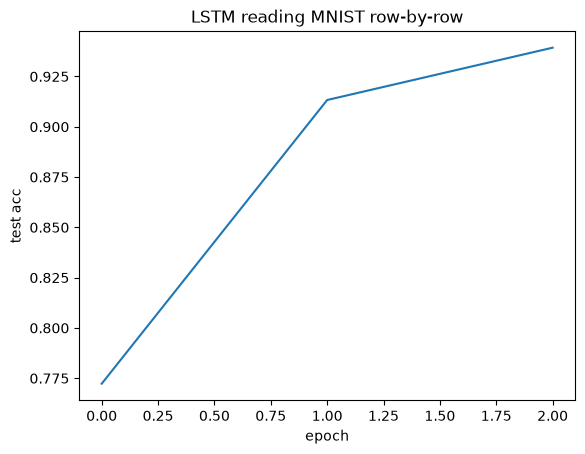

final test accuracy: 0.9393


In [2]:
plt.plot(history["val_acc"]); plt.xlabel("epoch"); plt.ylabel("test acc")
plt.title("LSTM reading MNIST row-by-row"); plt.show()
print("final test accuracy:", history["val_acc"][-1])

### Things to tweak
- `cell="gru"` vs `"lstm"` vs `"rnn"` - the plain `"rnn"` struggles on longer
  sequences (vanishing gradients); LSTM/GRU gate information through.
- `hidden_size`, `num_layers`.

### Contrast with A2
The CNN sees the whole grid at once and is translation-aware; the RNN must
*remember* earlier rows as it scans. On upright MNIST the CNN wins easily - the
right inductive bias matters. Picking the architecture that matches your data's
structure is the core skill these foundation notebooks build.